In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import display, Markdown   # 新导入（通过导入库解决文字问题，by deepseek）
#下面的引用借助deep seek解决小标题无法显示中文字符的问题
plt.rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [36]:
def equalize_hist(im, nbr_bins=256):            #图像均衡化函数定义
    """对一幅灰度图像进行直方图均衡化"""
    # 图像直方图统计
    imhist, bins = np.histogram(im.flatten(), nbr_bins)
    # 累积分布函数
    cdf = imhist.cumsum()    # 计算累积和，并归一化到 0~255。
    cdf = 255.0 * cdf / cdf[-1]
    # 使用累积分布函数的线性插值，计算新的像素值
    im2 = np.interp(im.flatten(), bins[:-1], cdf)  # 分段线性插值函数
    return im2.reshape(im.shape).astype(np.uint8), cdf   
    # 添加 .astype(np.uint8)（为解决弹窗画面太过偏白的措施，suggested by Deepseek）

## 运行的单帧结果：

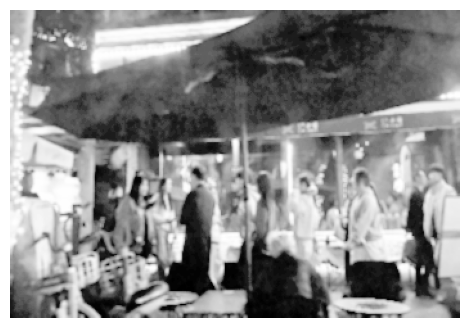

<center>图1-第1帧的结果</center>

In [37]:
v = cv2.VideoCapture('video/v.mp4')

if not v.isOpened():
    print("无法打开视频文件，请检查路径")
    exit()  
    
target_frame = 1
frame_count = 0
result_img = None


while True:
    re,frame = v.read()
    if not re:           # 视频结束或读取失败
        break
    frame_count += 1

    # 灰度化
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # 缩放
    image = cv2.resize(image, (350, 240))
    # 高斯去噪
    filtered_img = cv2.GaussianBlur(image, (3, 3), 1.5)
    # 直方图均衡化
    img_equalize_hist, cdf = equalize_hist(filtered_img)

    if frame_count == target_frame:
        result_img = img_equalize_hist

    
    cv2.imshow('result',img_equalize_hist)
    if cv2.waitKey(25) & 0xFF == 27:
        break
v.release()
cv2.destroyAllWindows()

if result_img is not None:
    display(Markdown("## 运行的单帧结果："))          # 大标题
    plt.figure(figsize=(6,4))
    plt.imshow(result_img, cmap='gray')
    plt.axis('off')
    plt.show()
    display(Markdown(f"<center>图1-第{target_frame}帧的结果</center>"))   # 图题居中
else:
    print(f"视频帧数不足，未能提取到第{target_frame}帧")

# 体会与收获：
## 1.对于老师提供的几个图像处理的程序，在ai和官方文档的帮助下弄懂了每一块的用法或含义。
## 2.对于程序中出现的问题（eg.窗口视频图像过白，文字无法正常显示），在deepseek的帮助下弄明白了为什么以及解决方法
## 3.巩固了python语法
## 4.修改了部分语句，学会如何让各个部分更加融洽。